In [ ]:
import sys
import os
import importlib
import random

src_path = os.path.abspath(os.path.join('..', 'src'))

if src_path not in sys.path:
    sys.path.append(src_path)

import src.preprocessing_data.pre_processing as pre_processing_module
import src.feature_engineering.build_features as build_features_module
import src.models.train_model as train_model_module
import src.visualization.visualize as visualize_module

importlib.reload(pre_processing_module)
importlib.reload(build_features_module)
importlib.reload(train_model_module)
importlib.reload(visualize_module)

from src.preprocessing_data.pre_processing import PreProcessor
from src.feature_engineering.build_features import LSTMFeatureEngineering
from src.models.train_model import LSTMTraining
from src.visualization.visualize import LSTMVisualizer

In [ ]:

NROWS = 1000000

processor = PreProcessor("../src/data/raw/balanced_10m_reviews.csv")
df = processor.preprocess(nrows=NROWS)

-------------------------
Current Dataframe has 999,978 rows and 20 columns.
No missing values found.

699,625 reviews are positive (70.0%) and 300,353 are negative (30.0%).

On average, authors have played for 13,758 minutes (median: 1,841, longest: 1,702,046).
At the time of writing, authors had played for 6,770 minutes on average (median: 823, longest: 1,595,502).

Reviews are 57.4 words long on average (median: 19, longest: 2,667 words).

Authors have written 36.2 reviews on average (median: 8, most prolific: 10,441).
Authors own 170.5 games on average (median: 0, most: 30,416).

Of the reviews in this dataframe:
  657,103 (65.7%) were purchased on Steam.
  35,501 (3.6%) were received for free.
  125,846 (12.6%) were written during early access.

The current dataframe covers 31,245 unique game(s).
-------------------------


In [ ]:
lstm_builder = LSTMFeatureEngineering(df=df, max_words=2000, max_len=100)

lstm_train_df, lstm_test_df = lstm_builder.split_data()

print(f"Training set: {len(lstm_train_df):,} rows")
print(f"Test set:     {len(lstm_test_df):,} rows")

Training set: 799,982 rows
Test set:     199,996 rows


In [ ]:
lstm_trainer = LSTMTraining(lstm_train_df, lstm_test_df)
lstm_trainer.set_features()
lstm_trainer.build_model()

c:\Users\Filip\miniconda3\envs\mlcourse\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
lstm_trainer.train()

Epoch 1/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 781s 35ms/step - accuracy: 0.8018 - loss: 0.4155 - val_accuracy: 0.8746 - val_loss: 0.3027
Epoch 2/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 776s 34ms/step - accuracy: 0.8788 - loss: 0.2881 - val_accuracy: 0.8851 - val_loss: 0.2797
Epoch 3/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 778s 35ms/step - accuracy: 0.8870 - loss: 0.2701 - val_accuracy: 0.8921 - val_loss: 0.2596
Epoch 4/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 779s 35ms/step - accuracy: 0.8923 - loss: 0.2586 - val_accuracy: 0.8897 - val_loss: 0.2711
Epoch 5/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 775s 34ms/step - accuracy: 0.8960 - loss: 0.2500 - val_accuracy: 0.8969 - val_loss: 0.2500
Epoch 6/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 778s 35ms/step - accuracy: 0.8992 - loss: 0.2429 - val_accuracy: 0.8919 - val_loss: 0.2613
Epoch 7/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 782s 35ms/step - accuracy: 0.9022 - loss: 0.2361 - val_accuracy: 0.8964 - val_loss: 0.2533
Epoch 8/10
22500/22500 ━━━━━━━━━━━━━━━━━━━━ 783s 35ms/s

In [ ]:
lstm_results = lstm_trainer.evaluate()

print("\nLSTM Results:")
for k, v in lstm_results.items():
    print(f"  {k}: {v}")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 65s 10ms/step

LSTM Results:
  loss: 0.26726940274238586
  accuracy: 0.8903978079561591
  precision: 0.9404387778715019
  recall: 0.9003680543148115
  f1_score: 0.9199672858978852
  confusion_matrix: [[ 52092   7979]
 [ 13941 125984]]


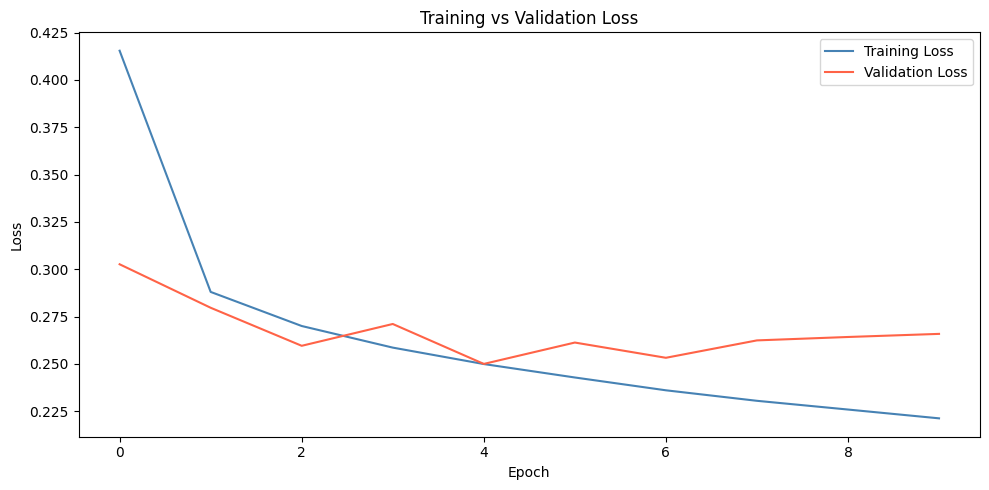

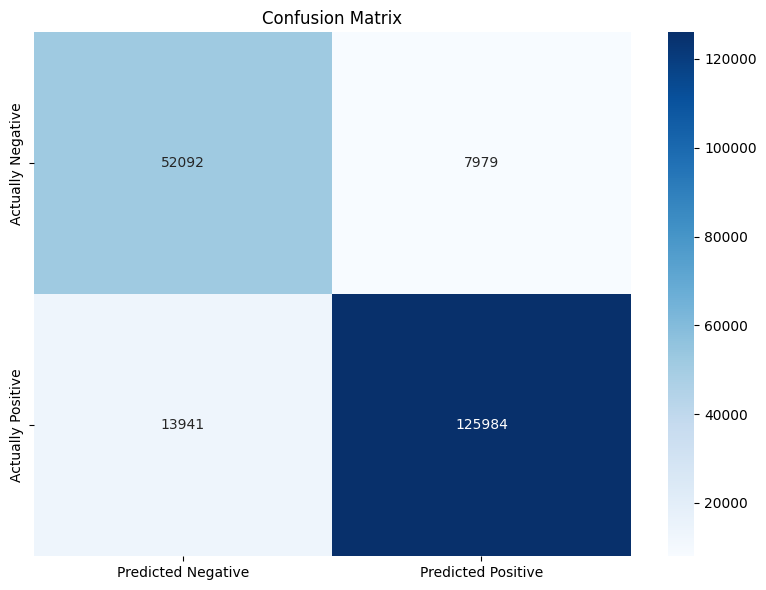

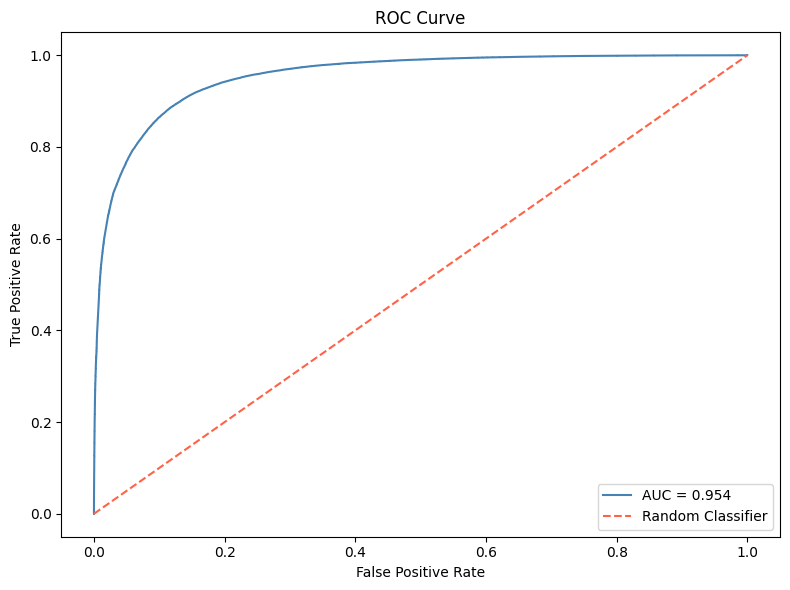

In [ ]:
lstm_plot = LSTMVisualizer(
    model=lstm_trainer.model,
    history=lstm_trainer.history,
    y_test=lstm_trainer.y_test,
    y_pred=lstm_trainer.y_pred,
    y_pred_proba=lstm_trainer.y_pred_proba
)

lstm_plot.plot_all()

In [ ]:
param_distributions = {
    "lstm_units":    [16, 32, 64, 128],
    "embedding_dim": [32, 50, 100],
    "epochs":        [5, 10],
    "batch_size":    [32, 64, 128]
}

N_ITER = 5

In [ ]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

results = []

for i in range(N_ITER):
    params = {k: random.choice(v) for k, v in param_distributions.items()}
    print(f"\nTrial {i+1}/{N_ITER}: {params}")

    trial_trainer = LSTMTraining(lstm_train_df, lstm_test_df)
    trial_trainer.set_features()

    trial_trainer.embedding_dim = params["embedding_dim"]
    trial_trainer.lstm_units = params["lstm_units"]
    trial_trainer.build_model()


    class_weight = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(trial_trainer.y_train),
        y=trial_trainer.y_train
    )
    class_weight_dict = dict(enumerate(class_weight))

    trial_trainer.model.fit(
        trial_trainer.X_train, trial_trainer.y_train,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        validation_split=0.1,
        class_weight=class_weight_dict,
        verbose=0
    )

    y_pred = (trial_trainer.model.predict(trial_trainer.X_test) > 0.5).astype(int).flatten()
    score = f1_score(trial_trainer.y_test, y_pred)
    print(f"  F1: {score:.4f}")

    results.append((score, params, trial_trainer.model))

results.sort(key=lambda x: x[0], reverse=True)
best_score, best_params, best_model = results[0]

print(f"\nBest parameters: {best_params}")
print(f"Best F1: {best_score:.4f}")


Trial 1/5: {'lstm_units': 16, 'embedding_dim': 50, 'epochs': 10, 'batch_size': 128}


c:\Users\Filip\miniconda3\envs\mlcourse\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 180s 29ms/step
  F1: 0.9122

Best parameters: {'lstm_units': 128, 'embedding_dim': 32, 'epochs': 10, 'batch_size': 64}
Best F1: 0.9237


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred_proba = best_model.predict(trial_trainer.X_test)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

print("Tuned LSTM Results:")
print(f"  Accuracy:  {accuracy_score(trial_trainer.y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(trial_trainer.y_test, y_pred):.4f}")
print(f"  Recall:    {recall_score(trial_trainer.y_test, y_pred):.4f}")
print(f"  F1:        {f1_score(trial_trainer.y_test, y_pred):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(trial_trainer.y_test, y_pred)}")

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 179s 29ms/step
Tuned LSTM Results:
  Accuracy:  0.8951
  Precision: 0.9407
  Recall:    0.9072
  F1:        0.9237
  Confusion Matrix:
[[ 52072   7999]
 [ 12986 126939]]


In [ ]:

best_model.save("../src/models/lstm_model_tuned.keras")
print(f"Saved best model with params: {best_params}")

Saved best model with params: {'lstm_units': 128, 'embedding_dim': 32, 'epochs': 10, 'batch_size': 64}
